**Análisis y preparación del dataset Student**

Información general del
Dataset

Nombre del dataset: Student Performance Factors


Fuente: Kaggle


Liga de acceso: https://www.kaggle.com/datasets/lainguyn123/student-performance-factors


Fecha de consulta: 14 de agosto de 2026

Última actualización reportada en Kaggle: actualización dentro de los últimos tres años al momento de realizar esta actividad.



Descripción

El conjunto de datos contiene información de 6,607 estudiantes y 20 variables relacionadas con factores académicos, personales, familiares y escolares que pueden influir en su desempeño académico. Entre las variables se encuentran las horas de estudio, asistencia, horas de sueño, calificaciones anteriores, tutorías, participación de los padres, acceso a recursos, motivación, tipo de escuela y otras características.

Cada registro representa a un estudiante y contiene información sobre sus hábitos, características personales y contexto educativo.

La variable Exam_Score representa el puntaje obtenido en el examen y puede utilizarse como variable objetivo para un problema de aprendizaje automático.

Debido a que Exam_Score es una variable numérica, el problema que podría abordarse posteriormente sería de aprendizaje supervisado de regresión, donde el modelo intentaría estimar el puntaje de examen de un estudiante a partir de las demás variables.

Un modelo de este tipo podría utilizarse para identificar factores relacionados con el desempeño académico y generar estimaciones que posteriormente podrían apoyar estrategias de seguimiento o intervención educativa.





En esta primera parte revisé de qué trata el dataset y qué información contiene. Me di cuenta de que cada fila representa a un estudiante y que hay diferentes factores que pueden estar relacionados con su desempeño, como las horas que estudia, su asistencia, sus horas de sueño, sus calificaciones anteriores y otros aspectos de su entorno.

Elegí **Exam_score** como la variable que podría predecir más adelante, porque es el resultado numérico que representa el puntaje del examen. Por eso, considero que este dataset podría utilizarse después para hacer un modelo de regresión y tratar de estimar el resultado de un estudiante.


In [46]:
import pandas as pd

In [47]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).




En esta parte cargué el archivo CSV para poder trabajar con los datos en Google Colab. Primero importé pandas, ya que es la librería que voy a utilizar principalmente para leer y analizar el dataset.


In [48]:
df = pd.read_csv('/content/StudentPerformanceFactors (1).csv')

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje



Aquí revisé cómo está formado el dataset. Encontré que tiene **6,607 registros y 20 columnas**. También revisé qué tipo de dato tiene cada columna y pude ver que algunas variables son numéricas y otras son categóricas.

Algo importante que encontré fueron algunos valores faltantes. Teacher_Quality tiene 78, Parental_Education_Level tiene 90 y Distance_from_Home tiene 67 valores faltantes. También revisé los registros duplicados y encontré que no hay duplicados.


**2. Importe las  librerías y cargue el CSV**

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

pd.set_option('display.max_columns', None)

df = pd.read_csv('/content/StudentPerformanceFactors (1).csv')

print("Dataset cargado correctamente.")
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Dataset cargado correctamente.
Filas: 6607
Columnas: 20


**Revise la estructura general**

In [51]:
print("Dimensiones:", df.shape)

print("\nNombres de columnas:")
print(df.columns.tolist())

print("\nTipos de datos:")
print(df.dtypes)

print("\nValores faltantes:")
print(df.isnull().sum())

print("\nRegistros duplicados:")
print(df.duplicated().sum())

print("\nValores únicos por columna:")
print(df.nunique(dropna=False))

Dimensiones: (6607, 20)

Nombres de columnas:
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']

Tipos de datos:
Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity          



En esta parte revisé algunas estadísticas de las variables numéricas, como el promedio, el valor mínimo, el máximo y la desviación estándar. Esto me ayudó a tener una idea de cómo están distribuidos los datos antes de comenzar a limpiarlos.

También revisé las variables categóricas para conocer qué categorías existen y cuántos registros pertenecen a cada una.


**Mostre las  estadísticas descriptivas**

In [52]:
print("Primeros 5 registros:")
display(df.head())

Primeros 5 registros:


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [53]:
print("Últimos 5 registros:")
display(df.tail())

Últimos 5 registros:


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68
6606,15,67,Medium,Low,Yes,9,94,Medium,Yes,0,Medium,Medium,Public,Positive,4,No,Postgraduate,Near,Male,64


In [54]:
print("Estadísticas descriptivas:")
display(df.describe())

Estadísticas descriptivas:


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


**Y tambien agregue las categoricas**

In [55]:
display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,NaN,NaN,NaN,19.975329,5.990594,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,NaN,NaN,NaN,79.977448,11.547475,60.0,70.0,80.0,90.0,100.0
Parental_Involvement,6607,3,Medium,3362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Access_to_Resources,6607,3,Medium,3319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Extracurricular_Activities,6607,2,Yes,3938,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sleep_Hours,6607.0,NaN,NaN,NaN,7.02906,1.46812,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,NaN,NaN,NaN,75.070531,14.399784,50.0,63.0,75.0,88.0,100.0
Motivation_Level,6607,3,Medium,3351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Internet_Access,6607,2,Yes,6108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tutoring_Sessions,6607.0,NaN,NaN,NaN,1.493719,1.23057,0.0,1.0,1.0,2.0,8.0




Después de revisar el dataset, busqué algunos problemas que pudieran afectar el análisis. Principalmente encontré valores faltantes en tres variables. También revisé si había registros duplicados, tipos de datos incorrectos, categorías inconsistentes y posibles valores fuera de rango.

En general, el dataset está bastante completo, pero sí es necesario tratar los valores faltantes antes de continuar con las siguientes partes.


**Diagnóstico de calidad**

In [56]:
diagnostico = pd.DataFrame({
    'Variable': df.columns,
    'Tipo': df.dtypes.astype(str).values,
    'Valores_faltantes': df.isnull().sum().values,
    'Duplicados': [df[c].duplicated().sum() for c in df.columns],
    'Valores_unicos': df.nunique(dropna=False).values
})

display(diagnostico)

,Variable,Tipo,Valores_faltantes,Duplicados,Valores_unicos
0,Hours_Studied,int64,0,6566,41
1,Attendance,int64,0,6566,41
2,Parental_Involvement,object,0,6604,3
3,Access_to_Resources,object,0,6604,3
4,Extracurricular_Activities,object,0,6605,2
5,Sleep_Hours,int64,0,6600,7
6,Previous_Scores,int64,0,6556,51
7,Motivation_Level,object,0,6604,3
8,Internet_Access,object,0,6605,2
9,Tutoring_Sessions,int64,0,6598,9


In [57]:
# Tabla de problemas de calidad

problemas = pd.DataFrame({
    'Problema detectado': [
        'Valores faltantes',
        'Valores faltantes',
        'Valores faltantes',
        'Registros duplicados',
        'Valor fuera de rango',
        'Valores atípicos',
        'Tipos de datos',
        'Variables constantes'
    ],

    'Variable afectada': [
        'Teacher_Quality',
        'Parental_Education_Level',
        'Distance_from_Home',
        'Todas',
        'Exam_Score',
        'Variables numéricas',
        'Todas',
        'Todas'
    ],

    'Evidencia': [
        f"{df['Teacher_Quality'].isna().sum()} valores faltantes",
        f"{df['Parental_Education_Level'].isna().sum()} valores faltantes",
        f"{df['Distance_from_Home'].isna().sum()} valores faltantes",
        f"{df.duplicated().sum()} registros duplicados",
        f"{(df['Exam_Score'] > 100).sum()} valor(es) mayor(es) a 100",
        'Se revisarán mediante IQR',
        'Se revisaron los tipos de datos',
        'Se revisará si existen columnas con un solo valor'
    ],

    'Tratamiento propuesto': [
        'Reemplazar por la moda',
        'Reemplazar por la moda',
        'Reemplazar por la moda',
        'No eliminar porque no existen duplicados',
        'Corregir al rango permitido de 0 a 100',
        'Revisar antes de eliminar',
        'Convertir si fuera necesario',
        'No eliminar si aportan información'
    ]
})

display(problemas)

,Problema detectado,Variable afectada,Evidencia,Tratamiento propuesto
0,Valores faltantes,Teacher_Quality,78 valores faltantes,Reemplazar por la moda
1,Valores faltantes,Parental_Education_Level,90 valores faltantes,Reemplazar por la moda
2,Valores faltantes,Distance_from_Home,67 valores faltantes,Reemplazar por la moda
3,Registros duplicados,Todas,0 registros duplicados,No eliminar porque no existen duplicados
4,Valor fuera de rango,Exam_Score,1 valor(es) mayor(es) a 100,Corregir al rango permitido de 0 a 100
5,Valores atípicos,Variables numéricas,Se revisarán mediante IQR,Revisar antes de eliminar
6,Tipos de datos,Todas,Se revisaron los tipos de datos,Convertir si fuera necesario
7,Variables constantes,Todas,Se revisará si existen columnas con un solo valor,No eliminar si aportan información




En esta parte revisé si algunas variables tenían valores que se alejaran mucho del resto. Para esto utilicé el método del IQR.

No quise eliminar automáticamente estos valores porque que sean diferentes no significa necesariamente que estén mal. Primero hay que revisar si realmente son valores imposibles o simplemente casos menos comunes.


**Revisar valores extremos**

In [58]:
numericas = df.select_dtypes(include=np.number).columns

for col in numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]

    print(f"{col}: {len(outliers)} posibles valores atípicos")

Hours_Studied: 43 posibles valores atípicos
Attendance: 0 posibles valores atípicos
Sleep_Hours: 0 posibles valores atípicos
Previous_Scores: 0 posibles valores atípicos
Tutoring_Sessions: 430 posibles valores atípicos
Physical_Activity: 0 posibles valores atípicos
Exam_Score: 104 posibles valores atípicos




Para comenzar la limpieza hice una copia del dataset original para no modificar directamente los datos originales. Después revisé los nombres de las columnas y los valores de las variables categóricas para evitar problemas por espacios o diferencias en la forma de escribir los datos.

También eliminé duplicados solamente si existían, pero en este caso no encontré registros duplicados.


***Limpieza del dataset***

In [59]:
df_limpio = df.copy()

In [60]:
df_limpio.columns = (
    df_limpio.columns
    .str.strip()
    .str.replace(' ', '_')
)

In [61]:
columnas_categoricas = df_limpio.select_dtypes(include='object').columns

for col in columnas_categoricas:
    df_limpio[col] = df_limpio[col].str.strip()

In [62]:
duplicados_antes = df_limpio.duplicated().sum()

df_limpio = df_limpio.drop_duplicates()

print("Duplicados encontrados:", duplicados_antes)
print("Duplicados después:", df_limpio.duplicated().sum())

Duplicados encontrados: 0
Duplicados después: 0




Aquí revisé específicamente la variable **Exam_Score** porque es la variable que podría utilizar como objetivo. Encontré un valor de 101, pero un examen normalmente debe estar entre 0 y 100.

Por eso decidí corregir ese valor a 100 en lugar de eliminar todo el registro. De esta manera conservo la información del estudiante y solamente corrijo el dato que estaba fuera del rango esperado.


**Corregir Exam_Score**

In [63]:
print("Valores de Exam_Score fuera de 0-100:")

display(
    df_limpio[
        (df_limpio['Exam_Score'] < 0) |
        (df_limpio['Exam_Score'] > 100)
    ]
)

Valores de Exam_Score fuera de 0-100:


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101


In [64]:
df_limpio.loc[df_limpio['Exam_Score'] > 100, 'Exam_Score'] = 100

In [65]:
print(df_limpio['Exam_Score'].min())
print(df_limpio['Exam_Score'].max())

55
100




Para solucionar los valores faltantes utilicé la categoría que aparece con mayor frecuencia en cada variable. Elegí esta opción porque las tres variables con valores faltantes son categóricas.

De esta manera no tuve que eliminar estudiantes completos y pude conservar la mayor cantidad de información posible del dataset.


**Tratar valores faltantes**

In [66]:
columnas_faltantes = [
    'Teacher_Quality',
    'Parental_Education_Level',
    'Distance_from_Home'
]

for col in columnas_faltantes:
    moda = df_limpio[col].mode()[0]
    df_limpio[col] = df_limpio[col].fillna(moda)
    print(f"{col}: valores faltantes reemplazados por '{moda}'")

Teacher_Quality: valores faltantes reemplazados por 'Medium'
Parental_Education_Level: valores faltantes reemplazados por 'High School'
Distance_from_Home: valores faltantes reemplazados por 'Near'


In [67]:
print("Valores faltantes después de la limpieza:")
display(df_limpio.isnull().sum())

Valores faltantes después de la limpieza:


,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0




En esta parte me enfoqué en **Exam_Score**, ya que es la variable que podría utilizar como objetivo en un modelo de regresión.

Primero revisé sus estadísticas y después hice un histograma y un diagrama de caja. Con el histograma puedo observar cómo se distribuyen los puntajes y con el diagrama de caja puedo identificar si existen valores que se alejan demasiado del resto.

Esto me ayuda a conocer mejor la variable antes de utilizarla en un modelo.


**Analizar Exam_Score**

In [68]:
print("Estadísticas de Exam_Score:")

display(df_limpio['Exam_Score'].describe())

Estadísticas de Exam_Score:


,Exam_Score
count,6607.000000
mean,67.235508
std,3.889161
min,55.000000
25%,65.000000
50%,67.000000
75%,69.000000
max,100.000000


**Histograma**

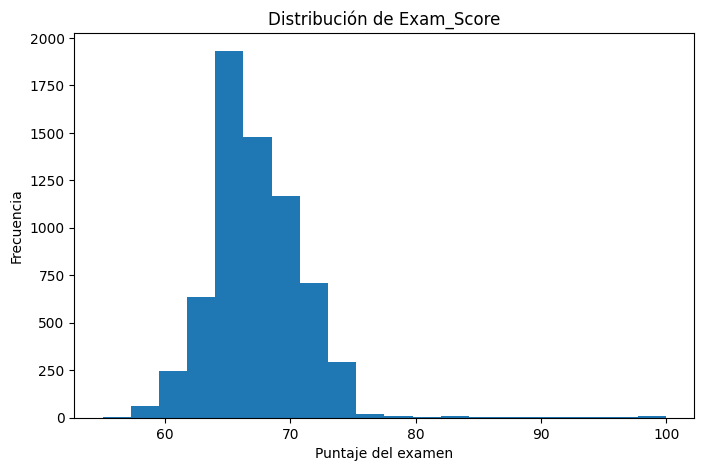

In [69]:
plt.figure(figsize=(8,5))

plt.hist(df_limpio['Exam_Score'], bins=20)

plt.title('Distribución de Exam_Score')
plt.xlabel('Puntaje del examen')
plt.ylabel('Frecuencia')

plt.show()

**Diagrama de caja:**

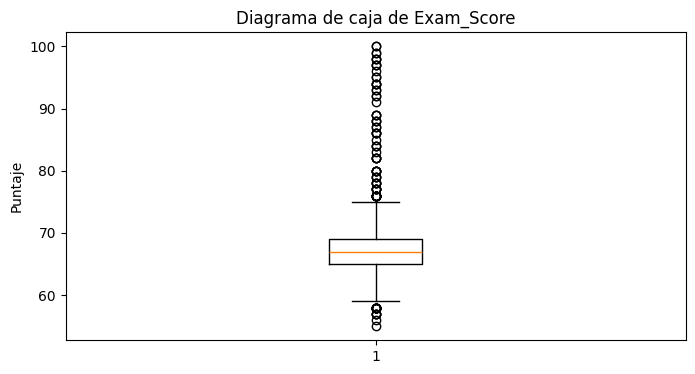

In [70]:
plt.figure(figsize=(8,4))

plt.boxplot(df_limpio['Exam_Score'])

plt.title('Diagrama de caja de Exam_Score')
plt.ylabel('Puntaje')

plt.show()

**Interpretación de Exam_Score**

La variable Exam_Score presenta una distribución concentrada principalmente alrededor de los valores medios. En el dataset original, los puntajes tienen un promedio aproximado de 67.24 puntos y un rango entre 55 y 101. Después de la limpieza, el valor 101 se corrige a 100 debido a que un puntaje superior a 100 no corresponde al rango esperado de una evaluación.

El diagrama de caja permite identificar posibles valores atípicos. Sin embargo, un valor atípico no necesariamente representa un error; por ello, únicamente se corrigió el valor que estaba fuera del rango lógico de la variable.

**Explorar variables numericas**

Vamos a utilizar:

Hours_Studied


Attendance


Sleep_Hours



Para ampliar el análisis seleccioné tres variables numéricas: Hours_Studied, Attendance y Sleep_Hours.

Elegí estas variables porque considero que pueden tener relación con el desempeño de un estudiante. Revisé sus estadísticas y también utilicé gráficas para observar cómo se distribuyen los datos y si existen valores que puedan considerarse extremos.

También hice una gráfica comparando Hours_Studied con Exam_Score para observar visualmente si existe alguna relación entre las horas de estudio y el puntaje obtenido.


In [71]:
variables_numericas = [
    'Hours_Studied',
    'Attendance',
    'Sleep_Hours'
]

display(df_limpio[variables_numericas].describe())

,Hours_Studied,Attendance,Sleep_Hours
count,6607.000000,6607.000000,6607.00000
mean,19.975329,79.977448,7.02906
std,5.990594,11.547475,1.46812
min,1.000000,60.000000,4.00000
25%,16.000000,70.000000,6.00000
50%,20.000000,80.000000,7.00000
75%,24.000000,90.000000,8.00000
max,44.000000,100.000000,10.00000


**Histograma de Hours_Studied**

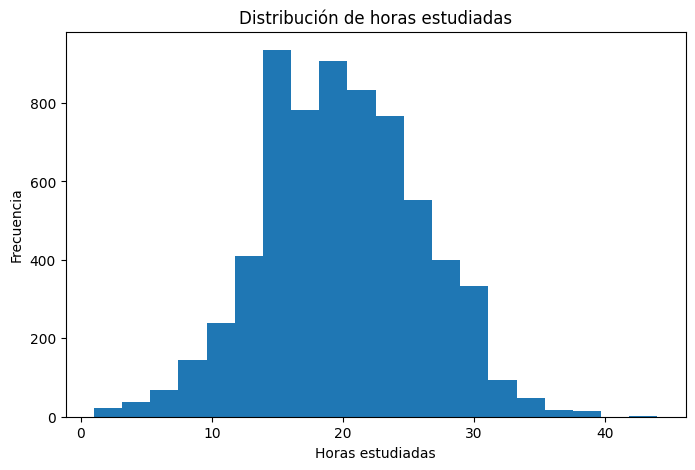

In [72]:
plt.figure(figsize=(8,5))

plt.hist(df_limpio['Hours_Studied'], bins=20)

plt.title('Distribución de horas estudiadas')
plt.xlabel('Horas estudiadas')
plt.ylabel('Frecuencia')

plt.show()

**Boxplot de Attendance**

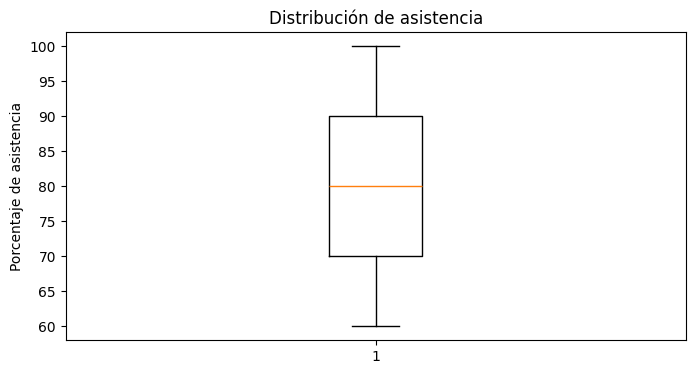

In [73]:
plt.figure(figsize=(8,4))

plt.boxplot(df_limpio['Attendance'])

plt.title('Distribución de asistencia')
plt.ylabel('Porcentaje de asistencia')

plt.show()

**Relación entre Hours_Studied y Exam_Score**

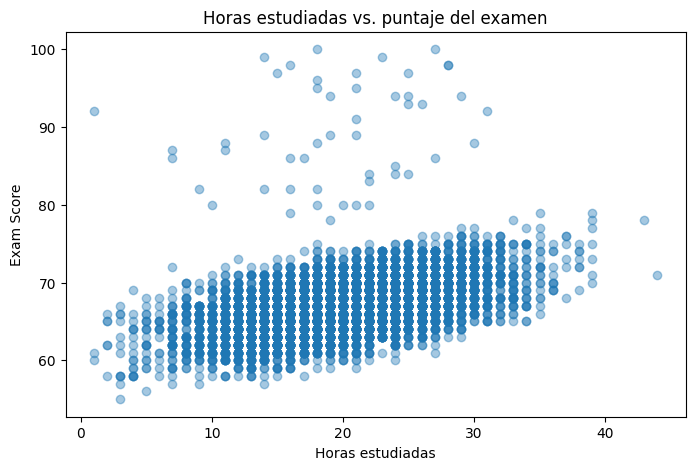

In [74]:
plt.figure(figsize=(8,5))

plt.scatter(
    df_limpio['Hours_Studied'],
    df_limpio['Exam_Score'],
    alpha=0.4
)

plt.title('Horas estudiadas vs. puntaje del examen')
plt.xlabel('Horas estudiadas')
plt.ylabel('Exam Score')

plt.show()



Para las variables categóricas seleccioné Parental_Involvement, Access_to_Resources, School_Type e Internet_Access.

Revisé cuántos estudiantes pertenecen a cada categoría. Esto me permite conocer cómo están distribuidos los estudiantes y detectar si existe alguna categoría que aparezca muy pocas veces o que pueda tener algún problema.


**Variables categóricas**

Vamos a usar:

Parental_Involvement


Access_to_Resources


School_Type


Internet_Access

In [75]:
variables_categoricas = [
    'Parental_Involvement',
    'Access_to_Resources',
    'School_Type',
    'Internet_Access'
]

for col in variables_categoricas:
    print(f"\n{col}")
    display(df_limpio[col].value_counts())


Parental_Involvement


,count
Parental_Involvement,
Medium,3362
High,1908
Low,1337



Access_to_Resources


,count
Access_to_Resources,
Medium,3319
High,1975
Low,1313



School_Type


,count
School_Type,
Public,4598
Private,2009



Internet_Access


,count
Internet_Access,
Yes,6108
No,499


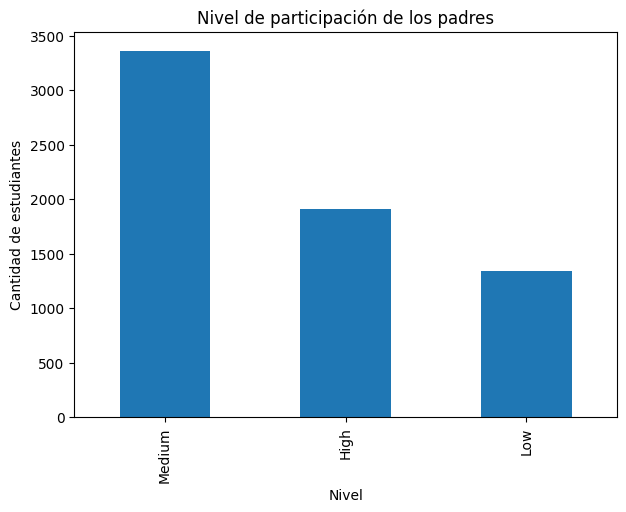

In [76]:
plt.figure(figsize=(7,5))

df_limpio['Parental_Involvement'].value_counts().plot(kind='bar')

plt.title('Nivel de participación de los padres')
plt.xlabel('Nivel')
plt.ylabel('Cantidad de estudiantes')

plt.show()

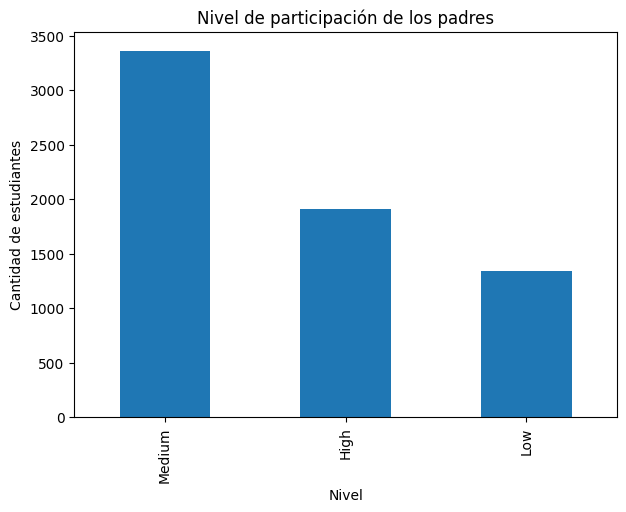

In [77]:
plt.figure(figsize=(7,5))

df_limpio['Parental_Involvement'].value_counts().plot(kind='bar')

plt.title('Nivel de participación de los padres')
plt.xlabel('Nivel')
plt.ylabel('Cantidad de estudiantes')

plt.show()

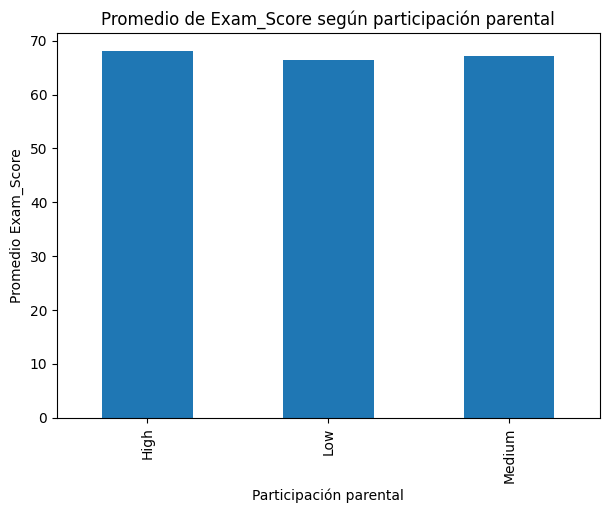

In [78]:
plt.figure(figsize=(7,5))

df_limpio.groupby('Parental_Involvement')['Exam_Score'].mean().plot(kind='bar')

plt.title('Promedio de Exam_Score según participación parental')
plt.xlabel('Participación parental')
plt.ylabel('Promedio Exam_Score')

plt.show()



En esta parte convertí algunas variables categóricas a números utilizando One-Hot Encoding. Lo utilicé principalmente para variables como School_Type e Internet_Access, porque sus categorías no tienen un orden.

Por ejemplo, no tendría sentido decir que una escuela pública vale 1 y una privada vale 2, porque eso podría hacer pensar al modelo que una categoría es mayor que la otra. Con One-Hot Encoding cada categoría tiene su propia columna.


**One-Hot Encoding**

In [79]:
from sklearn.preprocessing import OneHotEncoder

onehot = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

nominales = [
    'School_Type',
    'Internet_Access'
]

encoded = onehot.fit_transform(df_limpio[nominales])

encoded_df = pd.DataFrame(
    encoded,
    columns=onehot.get_feature_names_out(nominales),
    index=df_limpio.index
)

display(encoded_df.head())

,School_Type_Private,School_Type_Public,Internet_Access_No,Internet_Access_Yes
0,0.0,1.0,0.0,1.0
1,0.0,1.0,0.0,1.0
2,0.0,1.0,0.0,1.0
3,0.0,1.0,0.0,1.0
4,0.0,1.0,0.0,1.0




Para las variables que sí tienen un orden utilicé codificación ordinal. Por ejemplo, Low, Medium y High sí tienen un orden de menor a mayor.

Por eso en este caso sí tiene sentido convertirlas a valores numéricos. De esta manera se conserva el orden que ya existe en la información original.


**` Codificación ordinal`**

In [80]:
ordinales = [
    'Parental_Involvement',
    'Access_to_Resources',
    'Motivation_Level',
    'Family_Income',
    'Teacher_Quality'
]

orden = ['Low', 'Medium', 'High']

ordinal_encoder = OrdinalEncoder(
    categories=[orden] * len(ordinales)
)

ordinal_encoded = ordinal_encoder.fit_transform(
    df_limpio[ordinales]
)

ordinal_df = pd.DataFrame(
    ordinal_encoded,
    columns=ordinales,
    index=df_limpio.index
)

display(ordinal_df.head())

,Parental_Involvement,Access_to_Resources,Motivation_Level,Family_Income,Teacher_Quality
0,0.0,2.0,0.0,0.0,1.0
1,0.0,1.0,0.0,1.0,1.0
2,1.0,1.0,1.0,1.0,1.0
3,0.0,1.0,1.0,1.0,1.0
4,1.0,1.0,1.0,1.0,2.0




En esta parte utilicé StandardScaler para cambiar la escala de Hours_Studied y Attendance.

Antes las variables tenían valores en sus rangos originales y después de aplicar el escalamiento los valores quedan en una escala más parecida. Esto no significa que se pierda la información, solamente cambia la forma en la que están representados los números.

Esto es importante porque algunos modelos pueden verse afectados cuando una variable tiene valores mucho más grandes que otra.


**Escalamiento**

In [81]:
from sklearn.preprocessing import StandardScaler

variables_escaladas = [
    'Hours_Studied',
    'Attendance'
]

antes = df_limpio[variables_escaladas].head(5)

scaler = StandardScaler()

despues = scaler.fit_transform(
    df_limpio[variables_escaladas]
)

despues_df = pd.DataFrame(
    despues,
    columns=variables_escaladas
)

print("Antes:")
display(antes)

print("Después:")
display(despues_df.head())

Antes:


,Hours_Studied,Attendance
0,23,84
1,19,64
2,24,98
3,29,89
4,19,92


Después:


,Hours_Studied,Attendance
0,0.504942,0.348375
1,-0.162822,-1.383736
2,0.671882,1.560853
3,1.506587,0.781403
4,-0.162822,1.041220


**17. Pipeline + ColumnTransformer**



En esta parte organicé las transformaciones utilizando ColumnTransformer y Pipeline. Lo hice para tener en un solo proceso las diferentes transformaciones que necesitan las variables.

Así puedo separar las variables numéricas de las categóricas y aplicar a cada una el tratamiento que corresponde. También hace que el proceso sea más ordenado y fácil de repetir si después utilizo el dataset para crear un modelo.


In [82]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

nominales = [
    'School_Type',
    'Internet_Access'
]

ordinales = [
    'Parental_Involvement',
    'Access_to_Resources',
    'Motivation_Level',
    'Family_Income',
    'Teacher_Quality'
]

numericas = [
    'Hours_Studied',
    'Attendance'
]

preprocesamiento = ColumnTransformer(
    transformers=[
        (
            'numericas',
            StandardScaler(),
            numericas
        ),
        (
            'nominales',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            nominales
        ),
        (
            'ordinales',
            OrdinalEncoder(
                categories=[['Low','Medium','High']] * len(ordinales),
                handle_unknown='use_encoded_value',
                unknown_value=-1
            ),
            ordinales
        )
    ],
    remainder='passthrough'
)

pipeline = Pipeline([
    ('preprocesamiento', preprocesamiento)
])

X = df_limpio.drop(columns=['Exam_Score'])
y = df_limpio['Exam_Score']

X_transformado = pipeline.fit_transform(X)

print("Dimensiones originales:", X.shape)
print("Dimensiones después de transformación:", X_transformado.shape)

Dimensiones originales: (6607, 19)
Dimensiones después de transformación: (6607, 21)


**Aqui esta el dataset final preparado**



Después de realizar las transformaciones obtuve una nueva versión del dataset preparada para utilizarse posteriormente en un modelo.

Las variables categóricas que seleccioné ya están representadas numéricamente y las variables numéricas seleccionadas ya fueron escaladas. También mantuve Exam_Score, ya que es la variable que podría utilizar como objetivo.


In [83]:
X_transformado = pipeline.fit_transform(X)

nombres_transformados = pipeline.named_steps[
    'preprocesamiento'
].get_feature_names_out()

df_preparado = pd.DataFrame(
    X_transformado,
    columns=nombres_transformados,
    index=df_limpio.index
)

df_preparado['Exam_Score'] = y.values

display(df_preparado.head())

,numericas__Hours_Studied,numericas__Attendance,nominales__School_Type_Private,nominales__School_Type_Public,nominales__Internet_Access_No,nominales__Internet_Access_Yes,ordinales__Parental_Involvement,ordinales__Access_to_Resources,ordinales__Motivation_Level,ordinales__Family_Income,ordinales__Teacher_Quality,remainder__Extracurricular_Activities,remainder__Sleep_Hours,remainder__Previous_Scores,remainder__Tutoring_Sessions,remainder__Peer_Influence,remainder__Physical_Activity,remainder__Learning_Disabilities,remainder__Parental_Education_Level,remainder__Distance_from_Home,remainder__Gender,Exam_Score
0,0.504942,0.348375,0.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,1.0,No,7,73,0,Positive,3,No,High School,Near,Male,67
1,-0.162822,-1.383736,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,No,8,59,2,Negative,4,No,College,Moderate,Female,61
2,0.671882,1.560853,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,Yes,7,91,2,Neutral,4,No,Postgraduate,Near,Male,74
3,1.506587,0.781403,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,Yes,8,98,1,Negative,4,No,High School,Moderate,Male,71
4,-0.162822,1.04122,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,2.0,Yes,6,65,3,Neutral,4,No,College,Near,Female,70


**Comparación inicial vs final**



En esta comparación revisé cómo cambió el dataset después de realizar la limpieza y las transformaciones.

Al inicio tenía 6,607 registros y 20 variables. Los valores faltantes fueron tratados y no tenía registros duplicados. Al final, algunas variables aumentaron debido al One-Hot Encoding, ya que una variable categórica puede convertirse en varias columnas.

Aunque aumentó el número de variables, esto es normal porque ahora las categorías están representadas de una forma que puede ser utilizada por los algoritmos de aprendizaje automático.


In [84]:
comparacion = pd.DataFrame({
    'Elemento': [
        'Número de registros',
        'Número de variables',
        'Valores faltantes',
        'Registros duplicados',
        'Variables categóricas transformadas',
        'Variables numéricas escaladas'
    ],
    'Estado inicial': [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        'Variables categóricas originales',
        'Ninguna'
    ],
    'Estado final': [
        df_preparado.shape[0],
        df_preparado.shape[1],
        df_preparado.isnull().sum().sum(),
        df_preparado.duplicated().sum(),
        ', '.join(nominales + ordinales),
        ', '.join(numericas)
    ]
})

display(comparacion)

,Elemento,Estado inicial,Estado final
0,Número de registros,6607,6607
1,Número de variables,20,22
2,Valores faltantes,235,0
3,Registros duplicados,0,0
4,Variables categóricas transformadas,Variables categóricas originales,"School_Type, Internet_Access, Parental_Involve..."
5,Variables numéricas escaladas,Ninguna,"Hours_Studied, Attendance"


**Verifique que todo funcione **



Finalmente revisé que el dataset preparado no tuviera valores faltantes ni valores infinitos y comprobé que pudiera utilizarse correctamente después de todas las transformaciones.

Con esta revisión puedo asegurar que los datos quedaron preparados para el siguiente paso, que sería comenzar con la creación y evaluación de un modelo.


In [85]:
print("¿Existen valores faltantes?")
print(df_preparado.isnull().sum().sum())

print("\n¿Existen valores infinitos?")
print(np.isinf(df_preparado.select_dtypes(include=np.number)).sum().sum())

print("\nDimensiones finales:")
print(df_preparado.shape)

print("\nPrimeros registros:")
display(df_preparado.head())

¿Existen valores faltantes?
0

¿Existen valores infinitos?
0

Dimensiones finales:
(6607, 22)

Primeros registros:


,numericas__Hours_Studied,numericas__Attendance,nominales__School_Type_Private,nominales__School_Type_Public,nominales__Internet_Access_No,nominales__Internet_Access_Yes,ordinales__Parental_Involvement,ordinales__Access_to_Resources,ordinales__Motivation_Level,ordinales__Family_Income,ordinales__Teacher_Quality,remainder__Extracurricular_Activities,remainder__Sleep_Hours,remainder__Previous_Scores,remainder__Tutoring_Sessions,remainder__Peer_Influence,remainder__Physical_Activity,remainder__Learning_Disabilities,remainder__Parental_Education_Level,remainder__Distance_from_Home,remainder__Gender,Exam_Score
0,0.504942,0.348375,0.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,1.0,No,7,73,0,Positive,3,No,High School,Near,Male,67
1,-0.162822,-1.383736,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,No,8,59,2,Negative,4,No,College,Moderate,Female,61
2,0.671882,1.560853,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,Yes,7,91,2,Neutral,4,No,Postgraduate,Near,Male,74
3,1.506587,0.781403,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,Yes,8,98,1,Negative,4,No,High School,Moderate,Male,71
4,-0.162822,1.04122,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,2.0,Yes,6,65,3,Neutral,4,No,College,Near,Female,70


In [86]:
nombre_archivo = 'StudentPerformanceFactors_preparado.csv'

df_preparado.to_csv(
    nombre_archivo,
    index=False
)

print(f"Archivo exportado: {nombre_archivo}")

Archivo exportado: StudentPerformanceFactors_preparado.csv


In [87]:
from google.colab import files

files.download(nombre_archivo)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>



En esta actividad pude conocer y preparar el dataset Student Performance Factors. Primero revisé su estructura y encontré que tiene 6,607 registros y 20 variables. También pude identificar que existen variables numéricas y categóricas, además de algunos valores faltantes.

Uno de los principales problemas que encontré fueron los valores faltantes en Teacher_Quality, Parental_Education_Level y Distance_from_Home. Para solucionarlos utilicé la categoría que más se repetía en cada variable. También revisé Exam_Score y encontré un valor de 101, por lo que lo corregí a 100 porque ese es el límite que tiene sentido para un examen.

Después analicé diferentes variables numéricas y categóricas mediante estadísticas y gráficas. Esto me ayudó a entender mejor cómo están distribuidos los datos y a identificar posibles valores extremos.

También aprendí que no todas las variables categóricas se deben convertir de la misma manera. Utilicé One-Hot Encoding para las variables que no tienen un orden y codificación ordinal para las que sí tienen un orden, como Low, Medium y High. Además, utilicé StandardScaler para cambiar la escala de algunas variables numéricas.

Finalmente, organicé las transformaciones utilizando ColumnTransformer y Pipeline, y comprobé que los datos quedaran sin valores faltantes ni errores. El dataset ya está preparado para utilizarse posteriormente en un modelo de regresión donde Exam_Score podría ser la variable que se intenta predecir.

Como siguiente paso, sería necesario separar los datos en entrenamiento y prueba y después probar diferentes modelos para saber cuál funciona mejor. También tendría que cuidar que las transformaciones se hagan solamente con los datos de entrenamiento para evitar que la información del conjunto de prueba afecte el modelo.
